# Feature Engineering, Model Optimization & Performance Comparison

**Maincrafts Technology - Artificial Intelligence & Machine Learning Internship**  
**Task 2**

This notebook builds an enhanced California House Price Prediction workflow with feature scaling, multiple regression models, evaluation metrics, model comparison, visualization, and best-model saving.

## Project Objective

The objective is to compare multiple regression algorithms on the California Housing dataset and select the best-performing model using a reproducible evaluation workflow. The project demonstrates feature scaling, train-test validation, RMSE and R2 evaluation, performance visualization, and practical model persistence.

## Import Libraries

The workflow uses pandas and NumPy for data handling, scikit-learn for preprocessing, modeling, and evaluation, matplotlib for plots, and joblib for saving the selected model.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

BASE_DIR = Path.cwd()
PLOTS_DIR = BASE_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

## Dataset Loading

The official task requires the California Housing dataset loaded through `fetch_california_housing(as_frame=True)`. The target column is renamed to `HousePrice` for clarity.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy().rename(columns={"MedHouseVal": "HousePrice"})
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Overview

A quick inspection confirms the number of rows, columns, data types, and missing values before modeling.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']

Data types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


## Feature Engineering

The feature matrix contains the eight official California Housing predictors. The target variable is `HousePrice`, representing median house value in units of 100,000 dollars.

In [4]:
feature_names = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]
X = df[feature_names]
y = df["HousePrice"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
X.describe().T

Feature matrix shape: (20640, 8)
Target vector shape: (20640,)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


## Feature Scaling

Feature scaling is important because the input variables have very different numeric ranges. `StandardScaler` transforms each feature to a common scale, helping models learn from all features more fairly and improving workflow stability.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_preview = pd.DataFrame(X_scaled, columns=feature_names).head()
scaled_preview

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## Train-Test Split

The scaled data is split into 80% training and 20% testing data using `random_state=42` for reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


## Model Training

Three regression models are trained on the same training data: Linear Regression as a baseline, Ridge Regression as a regularized linear model, and a max-depth 5 Decision Tree Regressor for non-linear relationships.

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42),
}

fitted_models = {}
predictions_by_model = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results.append({"Model": name, "RMSE": rmse, "R2 Score": r2})
    fitted_models[name] = model
    predictions_by_model[name] = predictions

print("Models trained successfully.")

Models trained successfully.


## Model Comparison

The models are ranked from best to worst using the official selection rule: highest R2 score first, with lowest RMSE used as the tie-breaker.

In [8]:
comparison_df = pd.DataFrame(results).sort_values(
    by=["R2 Score", "RMSE"], ascending=[False, True]
).reset_index(drop=True)
comparison_df.to_csv(BASE_DIR / "model_comparison.csv", index=False)
comparison_df

,Model,RMSE,R2 Score
0,Decision Tree Regressor,0.724234,0.599732
1,Ridge Regression,0.745554,0.575819
2,Linear Regression,0.745581,0.575788


## Performance Evaluation

RMSE measures prediction error in the target scale, where lower is better. R2 measures explained variance, where higher is better. The ranked table is also saved to `metrics.json` for reproducible reporting.

In [9]:
best_model_name = comparison_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

metrics = {
    "project_title": "Feature Engineering, Model Optimization & Performance Comparison",
    "dataset": "California Housing dataset from sklearn.datasets.fetch_california_housing(as_frame=True)",
    "target_variable": "HousePrice",
    "features": feature_names,
    "row_count": int(df.shape[0]),
    "column_count": int(df.shape[1]),
    "missing_values": {column: int(value) for column, value in df.isna().sum().items()},
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "test_size_ratio": 0.20,
    "random_state": 42,
    "scaler": "StandardScaler",
    "models": comparison_df.to_dict(orient="records"),
    "best_model": str(best_model_name),
    "best_model_metrics": comparison_df.loc[0].to_dict(),
    "selection_rule": "Highest R2 Score; if tied, lowest RMSE",
}

with open(BASE_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics["best_model_metrics"], indent=2))

{
  "Model": "Decision Tree Regressor",
  "RMSE": 0.7242338143386247,
  "R2 Score": 0.5997321244428706
}


## Visualization

The charts below compare model performance, inspect actual versus predicted values for the selected model, and summarize feature importance or coefficient magnitude.

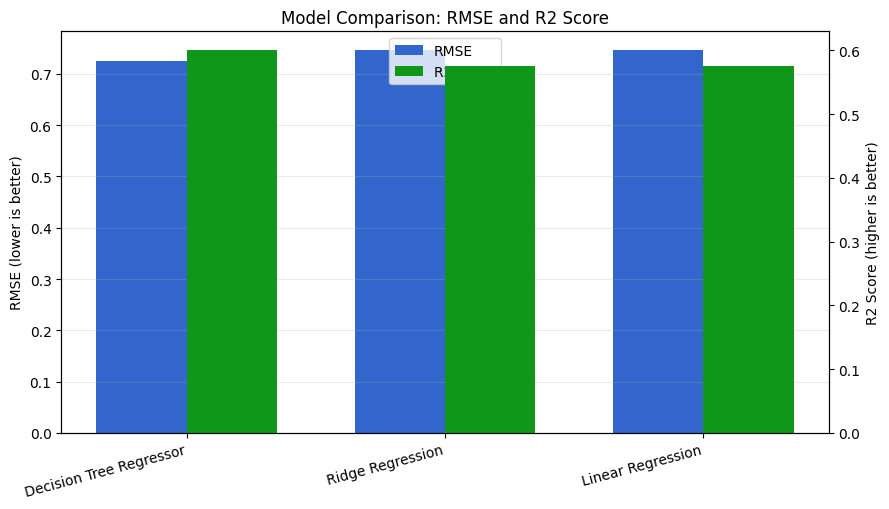

In [10]:
fig, ax1 = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x - width / 2, comparison_df["RMSE"], width, color="#3366cc", label="RMSE")
ax1.set_ylabel("RMSE (lower is better)")
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
ax1.grid(axis="y", alpha=0.25)
ax2 = ax1.twinx()
ax2.bar(x + width / 2, comparison_df["R2 Score"], width, color="#109618", label="R2 Score")
ax2.set_ylabel("R2 Score (higher is better)")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper center")
ax1.set_title("Model Comparison: RMSE and R2 Score")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "model_comparison.png", dpi=180)
plt.show()

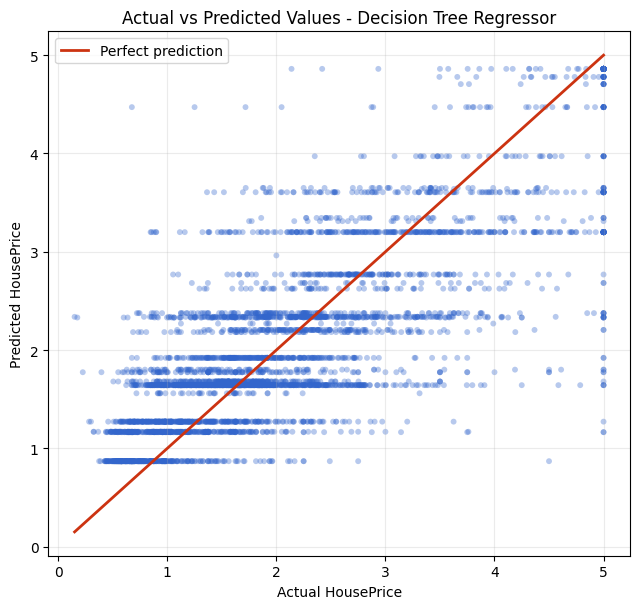

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6.2))
ax.scatter(y_test, best_predictions, alpha=0.35, s=18, color="#3366cc", edgecolors="none")
lower = min(float(y_test.min()), float(best_predictions.min()))
upper = max(float(y_test.max()), float(best_predictions.max()))
ax.plot([lower, upper], [lower, upper], color="#cc3311", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual HousePrice")
ax.set_ylabel("Predicted HousePrice")
ax.set_title(f"Actual vs Predicted Values - {best_model_name}")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "actual_vs_predicted.png", dpi=180)
plt.show()

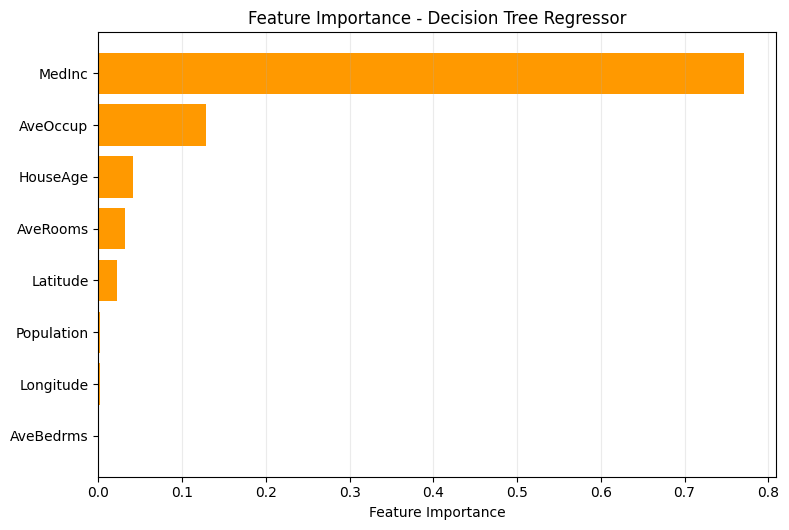

In [12]:
if hasattr(best_model, "feature_importances_"):
    importance_values = np.asarray(best_model.feature_importances_)
    importance_label = "Feature Importance"
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(np.asarray(best_model.coef_))
    importance_label = "Absolute Coefficient Magnitude"
else:
    importance_values = np.zeros(len(feature_names))
    importance_label = "Importance Proxy"

order = np.argsort(importance_values)
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.barh(np.asarray(feature_names)[order], importance_values[order], color="#ff9900")
ax.set_xlabel(importance_label)
ax.set_title(f"Feature Importance - {best_model_name}")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "feature_importance.png", dpi=180)
plt.show()

## Best Model Selection

The best model is selected automatically by highest R2 score and then lowest RMSE. This rule favors the model that explains the most variance while still considering prediction error.

In [13]:
print(f"Best model selected: {best_model_name}")
print(comparison_df.loc[0])

Best model selected: Decision Tree Regressor
Model       Decision Tree Regressor
RMSE                       0.724234
R2 Score                   0.599732
Name: 0, dtype: object


## Model Saving

The selected model is saved with joblib as `best_model.joblib`. The saved bundle includes the trained model, fitted scaler, feature names, target name, and selection rule. Loading it back verifies that it can be reused for inference.

In [14]:
model_bundle = {
    "model_name": str(best_model_name),
    "model": best_model,
    "scaler": scaler,
    "feature_names": feature_names,
    "target_name": "HousePrice",
    "selection_rule": "Highest R2 Score, then lowest RMSE",
}
joblib.dump(model_bundle, BASE_DIR / "best_model.joblib")

loaded_bundle = joblib.load(BASE_DIR / "best_model.joblib")
loaded_predictions = loaded_bundle["model"].predict(X_test[:5])
print("Reloaded model prediction sample:", loaded_predictions)

Reloaded model prediction sample: [1.16857267 1.27158128 3.19958174 2.20476301 1.64279735]


## Sample Predictions

At least 20 actual and predicted examples are exported for quick inspection.

In [15]:
sample_predictions = pd.DataFrame({
    "Actual Values": y_test.reset_index(drop=True).iloc[:20].round(4),
    "Predicted Values": np.round(best_predictions[:20], 4),
})
sample_predictions.to_csv(BASE_DIR / "sample_predictions.csv", index=False)
sample_predictions

,Actual Values,Predicted Values
0,0.477,1.1686
1,0.458,1.2716
2,5.000,3.1996
3,2.186,2.2048
4,2.780,1.6428
5,1.587,2.3379
6,1.982,1.9206
7,1.575,1.6428
8,3.400,2.3755
9,4.466,4.7788


## Conclusions

The comparison shows how model choice affects predictive performance. The selected model provides the strongest test-set R2 score under the required evaluation rule, while the linear models remain easier to interpret. This mirrors a professional ML workflow: preprocess consistently, train multiple candidates, compare objective metrics, visualize behavior, and persist the final model.

## Future Improvements

Future work can include cross-validation, hyperparameter tuning, additional feature engineering, residual analysis, and testing more robust models such as Random Forest, Gradient Boosting, or XGBoost. A production workflow should also fit preprocessing only on the training split through a scikit-learn Pipeline.